# Chapter 5 — GaAs band structure

Companion notebook to Chapter 5. We plot the Kohn–Sham bands that
`bands.x` wrote along the L–Γ–X–W–K–Γ path
(`code/05-bands/gaas.bands.dat.gnu`), align the valence-band maximum to
zero, and read off the band gap. Requirements: `numpy`, `matplotlib`.

In [1]:
import numpy as np
from pathlib import Path

d = Path('../code/05-bands')

# Parse the bands.x .gnu file: blank-line-separated blocks, one band each,
# every line is '<k-distance>  <energy(eV)>'.
blocks, cur = [], []
for line in (d/'gaas.bands.dat.gnu').read_text().splitlines():
    if line.strip():
        k, e = line.split()[:2]
        cur.append((float(k), float(e)))
    elif cur:
        blocks.append(np.array(cur)); cur = []
if cur: blocks.append(np.array(cur))

kdist = blocks[0][:, 0]
bands = np.array([b[:, 1] for b in blocks])   # shape (nbnd, nk)
nbnd, nk = bands.shape
print(f'{nbnd} bands, {nk} k-points along the path')

# GaAs: 18 electrons -> 9 occupied bands. VBM = top of band 9, CBM = bottom of band 10.
NOCC = 9
vbm = bands[NOCC-1].max()
cbm = bands[NOCC].min()
kv = kdist[bands[NOCC-1].argmax()]
kc = kdist[bands[NOCC].argmin()]
print(f'VBM = {vbm:.4f} eV, CBM = {cbm:.4f} eV')
print(f'PBE band gap = {cbm - vbm:.3f} eV   (experiment 1.42 eV)')
print(f'direct? VBM and CBM at same k: {abs(kv - kc) < 1e-6}')

16 bands, 181 k-points along the path
VBM = 7.6178 eV, CBM = 8.1319 eV
PBE band gap = 0.514 eV   (experiment 1.42 eV)
direct? VBM and CBM at same k: True


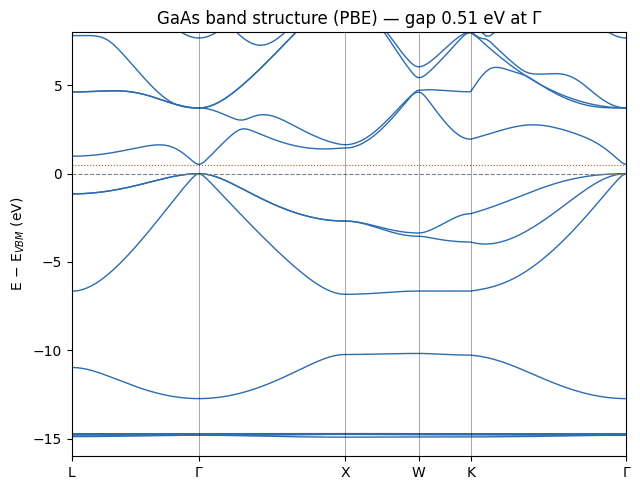

In [2]:
import matplotlib.pyplot as plt

# High-symmetry tick positions + labels (from bands.x output).
ticks, labels = [], []
for line in (d/'highsym.dat').read_text().splitlines():
    if line.strip() and not line.startswith('#'):
        x, lab = line.split()
        ticks.append(float(x)); labels.append(lab)

fig, ax = plt.subplots(figsize=(6.5, 5))
for b in bands:
    ax.plot(kdist, b - vbm, color='#2b6cb0', lw=1.0)
ax.axhline(0.0, color='gray', lw=0.8, ls='--')                 # VBM
ax.axhline(cbm - vbm, color='#c05621', lw=0.8, ls=':')          # CBM
for x in ticks:
    ax.axvline(x, color='k', lw=0.6, alpha=0.4)
ax.set_xticks(ticks); ax.set_xticklabels(labels)
ax.set_xlim(kdist.min(), kdist.max())
ax.set_ylim(-16, 8)
ax.set_ylabel('E − E$_{VBM}$ (eV)')
ax.set_title(f'GaAs band structure (PBE) — gap {cbm-vbm:.2f} eV at Γ')
ax.grid(False)
fig.tight_layout()
fig.savefig(d.parent.parent/'static/img/05-bands.png', dpi=120)
plt.show()

**What you see.** The valence-band maximum and the conduction-band
minimum both sit at **Γ** — GaAs is a **direct-gap** semiconductor. The
flat five-band cluster near −14.8 eV (bottom of the plot) is the Ga 3d
semicore manifold from Chapter 1; the single band near −12.7 eV at Γ is
the As 4s state. The computed PBE gap is far smaller than the experimental
1.42 eV: this is the notorious **band-gap problem** of semilocal DFT —
Kohn–Sham eigenvalue differences are not true quasiparticle energies, and
GaAs is an extreme case (PBE can even close the gap). Fixing it needs
hybrids or GW, beyond this tutorial.